In [1]:
%matplotlib widget

In [2]:
# 3D forward dipping boundary

# Script to create synthetic 3D data

import numpy as np
import emg3d 
import empymod as ep
import pandas as pd
from scipy.constants import mu_0
import matplotlib.pyplot as plt
import time
from joblib import Parallel, delayed
import sys
sys.path.insert(1, 'src')

In [3]:
data = np.load('dataUC.npy')

In [4]:
alphas = np.arange(-10, 10)
sigmas = np.array([[200/1000, 20/1000],
                   [400/1000, 20/1000],
                   [800/1000, 20/1000],
                   [1600/1000, 20/1000]])

idx=np.argmin(np.abs(alphas))

In [5]:
data = data.reshape((len(alphas), len(sigmas), 18))

In [6]:
dat_0 = np.zeros_like(data)

for i, a in enumerate(alphas):
    for j, s in enumerate(sigmas):
        dat_0[i, j, :] = data[idx, j, :]

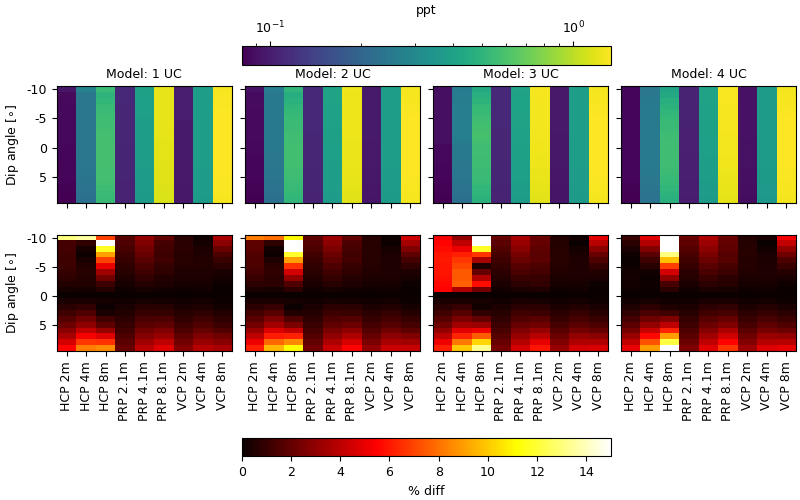

In [7]:
fig, axs = plt.subplots(2,4, figsize=(8, 5), sharex=True, sharey=True, layout='constrained')

ax = axs.ravel()
cmap='hot'
fs=9
keys = ['HCP 2m', 'HCP 4m', 'HCP 8m', 'PRP 2.1m', 'PRP 4.1m', 'PRP 8.1m', 'VCP 2m', 'VCP 4m', 'VCP 8m', ] 

for i, s in enumerate(sigmas):
    j = i
    c1 = ax[j].imshow(data[:, i, :9]*1000, aspect = .3, norm='log') 
    ax[j].set_title('Model: ' + str(i+1) +' UC', fontsize=fs)
    
   # ax[j+8].imshow(data[:, i, 9:].T, aspect = 5) 
    c2 = ax[j+4].imshow(np.abs((data[:,i, :9] - dat_0[:,i,:9])/dat_0[:, i, :9])*100, cmap=cmap, aspect=.3, vmin=0, vmax=15)
    
    ax[j].set_xticks(np.arange(0,9))
    ax[j+4].set_xticklabels(keys, rotation ='vertical')
    ax[j].set_yticks(np.arange(0,20,5))
    ax[j].set_yticklabels(['-10', '-5', '0', '5', ], )
    ax[j].tick_params(labelsize=fs)
    ax[j+4].tick_params(labelsize=fs)

cb1 = fig.colorbar(c1, ax=ax, location = 'top', shrink=0.5, pad = 0.01)
cb2 = fig.colorbar(c2, ax=ax, location = 'bottom', shrink=0.5, pad=0.05)

axs[0,0].set_ylabel('Dip angle [$\circ$]', fontsize=fs)
axs[1,0].set_ylabel('Dip angle [$\circ$]', fontsize=fs)

cb2.ax.tick_params(labelsize=fs)
cb2.set_label('% diff', fontsize=fs)

cb1.ax.tick_params(labelsize=fs)
cb1.set_label('ppt', fontsize=fs)

plt.savefig('DippingBoundaryUC_Q.eps', format='eps')

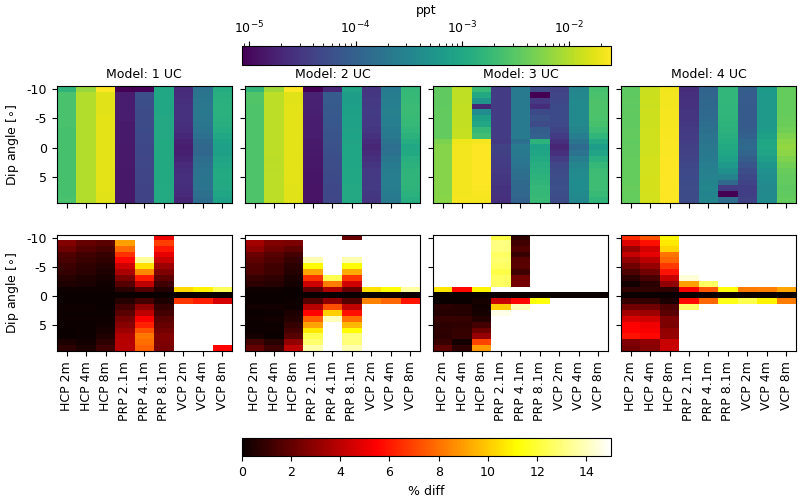

In [8]:
fig, axs = plt.subplots(2,4, figsize=(8, 5), sharex=True, sharey=True, layout='constrained')

ax = axs.ravel()
cmap='hot'
fs=9
keys = ['HCP 2m', 'HCP 4m', 'HCP 8m', 'PRP 2.1m', 'PRP 4.1m', 'PRP 8.1m', 'VCP 2m', 'VCP 4m', 'VCP 8m', ] 

for i, s in enumerate(sigmas):
    j = i
    c1 = ax[j].imshow(data[:, i, 9:]*1000, aspect = .3, norm='log') 
    ax[j].set_title('Model: ' + str(i+1) +' UC', fontsize=fs)
    
   # ax[j+8].imshow(data[:, i, 9:].T, aspect = 5) 
    c2 = ax[j+4].imshow(np.abs((data[:,i, 9:] - dat_0[:,i,9:])/dat_0[:, i, 9:])*100, cmap=cmap, aspect=.3, vmin=0, vmax=15)
    
    ax[j].set_xticks(np.arange(0,9))
    ax[j+4].set_xticklabels(keys, rotation ='vertical')
    ax[j].set_yticks(np.arange(0,20,5))
    ax[j].set_yticklabels(['-10', '-5', '0', '5', ], )
    ax[j].tick_params(labelsize=fs)
    ax[j+4].tick_params(labelsize=fs)

cb1 = fig.colorbar(c1, ax=ax, location = 'top', shrink=0.5, pad = 0.01)
cb2 = fig.colorbar(c2, ax=ax, location = 'bottom', shrink=0.5, pad=0.05)

axs[0,0].set_ylabel('Dip angle [$\circ$]', fontsize=fs)
axs[1,0].set_ylabel('Dip angle [$\circ$]', fontsize=fs)

cb2.ax.tick_params(labelsize=fs)
cb2.set_label('% diff', fontsize=fs)

cb1.ax.tick_params(labelsize=fs)
cb1.set_label('ppt', fontsize=fs)

plt.savefig('DippingBoundaryUC_IP.eps', format='eps')

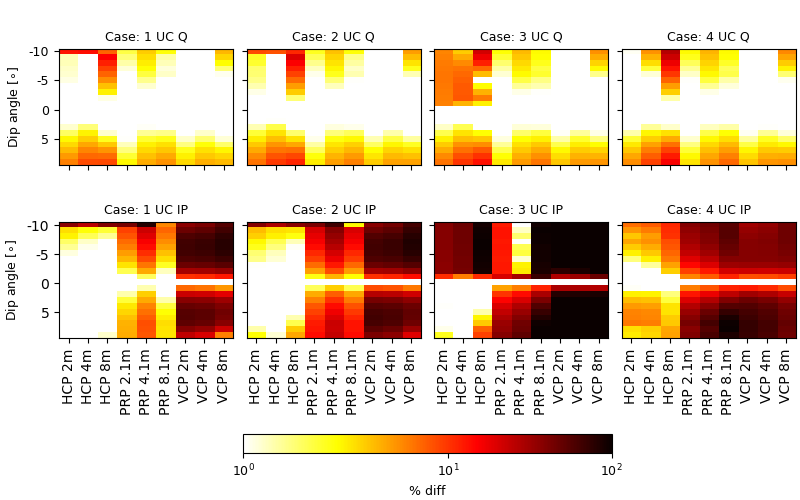

In [26]:
fig, axs = plt.subplots(2,4, figsize=(8, 5), sharex=True, sharey=True, layout='constrained')

ax = axs.ravel()
cmap='hot_r'
fs=9
keys = ['HCP 2m', 'HCP 4m', 'HCP 8m', 'PRP 2.1m', 'PRP 4.1m', 'PRP 8.1m', 'VCP 2m', 'VCP 4m', 'VCP 8m', ] 

for i, s in enumerate(sigmas):
    j = i
    c1 = ax[j].imshow(np.abs((data[:,i, :9] - dat_0[:,i,:9])/dat_0[:, i, :9])*100, cmap=cmap, aspect=.3, vmin=1, vmax=100, norm='symlog')
    c2 = ax[j+4].imshow(np.abs((data[:,i, 9:] - dat_0[:,i,9:])/dat_0[:, i, 9:])*100, cmap=cmap, aspect=.3, vmin=1, vmax=100, norm='symlog')
    ax[j].set_title('Case: ' + str(i+1) +' UC Q', fontsize=fs)
    ax[j+ 4].set_title('Case: ' + str(i+1) +' UC IP', fontsize=fs)
    
    ax[j].set_xticks(np.arange(0,9))
    ax[j+4].set_xticklabels(keys, rotation ='vertical')
    ax[j].set_yticks(np.arange(0,20,5))
    ax[j].set_yticklabels(['-10', '-5', '0', '5', ], )
    ax[j].tick_params(labelsize=fs)
    ax[j].tick_params(labelsize=fs)

#cb1 = fig.colorbar(c1, ax=ax, location = 'top', shrink=0.5, pad = 0.01)
cb2 = fig.colorbar(c2, ax=ax, location = 'bottom', shrink=0.5, pad=0.05)

axs[0,0].set_ylabel('Dip angle [$\circ$]', fontsize=fs)
axs[1,0].set_ylabel('Dip angle [$\circ$]', fontsize=fs)

cb2.ax.tick_params(labelsize=fs)
cb2.set_label('% diff', fontsize=fs)

#cb1.ax.tick_params(labelsize=fs)
#cb1.set_label('ppt', fontsize=fs)

plt.savefig('DippingBoundaryUC.eps', format='eps')

In [80]:
difference = np.abs(data*1000 - dat_0*1000)
percentage =  np.abs(data - dat_0)/np.abs(dat_0)

In [72]:
import pandas as pd

diff = pd.DataFrame(difference.reshape(20*4,18), columns = ['HCP_2m_Q', 'HCP_4m_Q', 'HCP_8m_Q', 'PRP_2.1m_Q', 'PRP_4.1m_Q', 'PRP_8.1m_Q',
                                                            'VCP_2m_Q', 'VCP_4m_Q', 'VCP_8m_Q', 'HCP_2m_IP', 'HCP_4m_IP', 'HCP_8m_IP',
                                                            'PRP_2.1m_IP', 'PRP_4.1m_IP', 'PRP_8.1m_IP', 'VCP_2m_IP', 'VCP_4m_IP', 'VCP_8m_IP', ] )

In [73]:
diff

,HCP_2m_Q,HCP_4m_Q,HCP_8m_Q,PRP_2.1m_Q,PRP_4.1m_Q,PRP_8.1m_Q,VCP_2m_Q,VCP_4m_Q,VCP_8m_Q,HCP_2m_IP,HCP_4m_IP,HCP_8m_IP,PRP_2.1m_IP,PRP_4.1m_IP,PRP_8.1m_IP,VCP_2m_IP,VCP_4m_IP,VCP_8m_IP
0,0.001312,0.004189,0.005324,0.000227,0.001513,0.003236,0.000081,0.000063,0.006580,0.002022,0.005467,0.015012,0.000015,0.000093,0.000128,0.000014,0.000117,0.000984
1,0.001669,0.004869,0.015915,0.000497,0.003283,0.006481,0.000146,0.000068,0.015303,0.002310,0.006512,0.013622,0.000018,0.000110,0.000047,0.000021,0.000175,0.001536
2,0.002155,0.003779,0.059500,0.001068,0.006984,0.013528,0.000265,0.000397,0.033142,0.002929,0.012939,0.028815,0.000007,0.000003,0.001079,0.000029,0.000249,0.002208
3,0.000897,0.012352,0.149493,0.002237,0.014558,0.027081,0.000492,0.001146,0.069594,0.000234,0.001030,0.002628,0.000015,0.000090,0.000579,0.000041,0.000352,0.003040
4,0.000130,0.000262,0.011471,0.000201,0.001322,0.002214,0.000083,0.000139,0.005241,0.000149,0.000434,0.000701,0.000003,0.000025,0.000168,0.000018,0.000146,0.001141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,0.003479,0.018680,0.068857,0.002273,0.016050,0.070039,0.002503,0.014583,0.052117,0.000096,0.000421,0.001002,0.000014,0.000112,0.001073,0.000094,0.000637,0.003282
76,0.000555,0.002553,0.006550,0.000281,0.001945,0.007773,0.000329,0.001891,0.006498,0.000045,0.000099,0.000470,0.000001,0.000009,0.000061,0.000010,0.000056,0.000097
77,0.001249,0.005842,0.016106,0.000609,0.004250,0.017647,0.000711,0.004132,0.014742,0.000127,0.000277,0.001502,0.000006,0.000039,0.000299,0.000023,0.000145,0.000458
78,0.002515,0.012180,0.037071,0.001271,0.008907,0.037873,0.001482,0.008659,0.031644,0.000145,0.000227,0.002823,0.000022,0.000159,0.001274,0.000045,0.000289,0.001141


In [74]:
case = []

for a in alphas:
    for s in range(len(sigmas)):
        case.append([a, s+1])

case = np.array(case)

In [75]:
diff['alpha'] = case[:,0]

In [76]:
diff['case'] = case[:,1]

In [77]:
diff

,HCP_2m_Q,HCP_4m_Q,HCP_8m_Q,PRP_2.1m_Q,PRP_4.1m_Q,PRP_8.1m_Q,VCP_2m_Q,VCP_4m_Q,VCP_8m_Q,HCP_2m_IP,HCP_4m_IP,HCP_8m_IP,PRP_2.1m_IP,PRP_4.1m_IP,PRP_8.1m_IP,VCP_2m_IP,VCP_4m_IP,VCP_8m_IP,alpha,case
0,0.001312,0.004189,0.005324,0.000227,0.001513,0.003236,0.000081,0.000063,0.006580,0.002022,0.005467,0.015012,0.000015,0.000093,0.000128,0.000014,0.000117,0.000984,-10,1
1,0.001669,0.004869,0.015915,0.000497,0.003283,0.006481,0.000146,0.000068,0.015303,0.002310,0.006512,0.013622,0.000018,0.000110,0.000047,0.000021,0.000175,0.001536,-10,2
2,0.002155,0.003779,0.059500,0.001068,0.006984,0.013528,0.000265,0.000397,0.033142,0.002929,0.012939,0.028815,0.000007,0.000003,0.001079,0.000029,0.000249,0.002208,-10,3
3,0.000897,0.012352,0.149493,0.002237,0.014558,0.027081,0.000492,0.001146,0.069594,0.000234,0.001030,0.002628,0.000015,0.000090,0.000579,0.000041,0.000352,0.003040,-10,4
4,0.000130,0.000262,0.011471,0.000201,0.001322,0.002214,0.000083,0.000139,0.005241,0.000149,0.000434,0.000701,0.000003,0.000025,0.000168,0.000018,0.000146,0.001141,-9,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,0.003479,0.018680,0.068857,0.002273,0.016050,0.070039,0.002503,0.014583,0.052117,0.000096,0.000421,0.001002,0.000014,0.000112,0.001073,0.000094,0.000637,0.003282,8,4
76,0.000555,0.002553,0.006550,0.000281,0.001945,0.007773,0.000329,0.001891,0.006498,0.000045,0.000099,0.000470,0.000001,0.000009,0.000061,0.000010,0.000056,0.000097,9,1
77,0.001249,0.005842,0.016106,0.000609,0.004250,0.017647,0.000711,0.004132,0.014742,0.000127,0.000277,0.001502,0.000006,0.000039,0.000299,0.000023,0.000145,0.000458,9,2
78,0.002515,0.012180,0.037071,0.001271,0.008907,0.037873,0.001482,0.008659,0.031644,0.000145,0.000227,0.002823,0.000022,0.000159,0.001274,0.000045,0.000289,0.001141,9,3


In [81]:
perc = pd.DataFrame(percentage.reshape(20*4,18), columns = ['HCP_2m_Q', 'HCP_4m_Q', 'HCP_8m_Q', 'PRP_2.1m_Q', 'PRP_4.1m_Q', 'PRP_8.1m_Q',
                                                            'VCP_2m_Q', 'VCP_4m_Q', 'VCP_8m_Q', 'HCP_2m_IP', 'HCP_4m_IP', 'HCP_8m_IP',
                                                            'PRP_2.1m_IP', 'PRP_4.1m_IP', 'PRP_8.1m_IP', 'VCP_2m_IP', 'VCP_4m_IP', 'VCP_8m_IP', ] )

In [82]:
perc['alpha'] = case[:,0]
perc['case'] = case[:,1]

In [79]:
diff.to_pickle('difference.pkl')

In [83]:
perc.to_pickle('percentage.pkl')